In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DIR = Path('/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full')

In [3]:
metagrads = np.load(DIR / 'metagrads.npy')

metagrads.shape

(12288000,)

In [90]:
metagrads.reshape(-1, 1024).max(1)[2200:]

array([5.2227435e-05, 6.4384927e-05, 4.7136196e-05, ..., 1.6242651e-04,
       1.7209238e-04, 1.2798724e-04], shape=(9800,), dtype=float32)

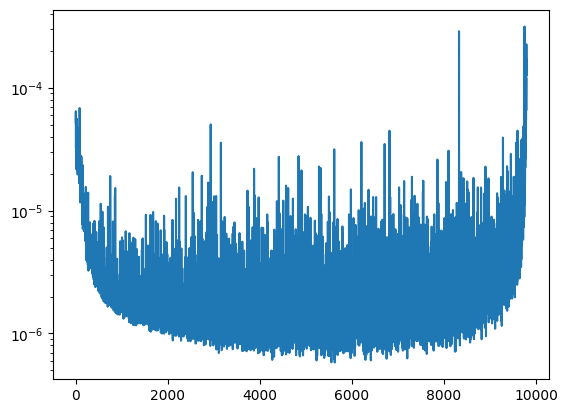

In [91]:
plt.plot(metagrads.reshape(-1, 1024).max(1)[2200:])
plt.yscale('log')

In [ ]:
np.where(metagrads != 0)[0] / 1024 # 1520 is where metagrads stopped

array([ 1520.        ,  1520.00097656,  1520.00195312, ...,
       11999.99707031, 11999.99804688, 11999.99902344], shape=(10731520,))

In [ ]:
import jax
import jax.numpy as jnp
gt_rewards = []
gt_rewards_v2 = []
preds = []

T = 2_100
BS = 1024
total = (12000 - 2100) * BS

for i in range(1,20):
    path = DIR / f'rand_cfx/{i}.npy'
    reward = np.load(path)
    data_weight_vector = jax.random.bernoulli(jax.random.PRNGKey(i), 0.95, 12000*BS).astype(jnp.float32)
    gt_rewards.append(reward)
    path = DIR / f'rand_cfx_v3/{i}.npy'
    reward_v2 = np.load(path)
    gt_rewards_v2.append(reward_v2)
    preds.append(np.dot(data_weight_vector[T*BS:], metagrads[T*BS:]).item())

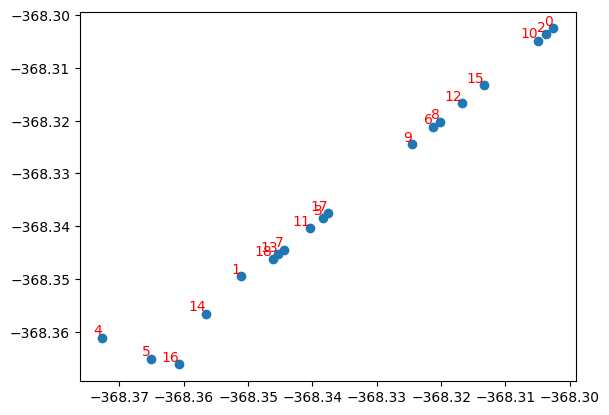

In [9]:
plt.scatter(gt_rewards, gt_rewards_v2)
for i, (x, y) in enumerate(zip(gt_rewards, gt_rewards_v2)):
    plt.text(x, y, str(i), fontsize=10, ha='right', va='bottom', color='red')

In [12]:
for i, (x, y) in enumerate(zip(gt_rewards, gt_rewards_v2)):
    print(i, x, y, x != y)

0 -368.30255 -368.30255 False
1 -368.35117 -368.34946 True
2 -368.30368 -368.30368 False
3 -368.33838 -368.33838 False
4 -368.37265 -368.3611 True
5 -368.36508 -368.36508 False
6 -368.3212 -368.3212 False
7 -368.34448 -368.34448 False
8 -368.3202 -368.3202 False
9 -368.3245 -368.3245 False
10 -368.30487 -368.30487 False
11 -368.3404 -368.3404 False
12 -368.31674 -368.31674 False
13 -368.34528 -368.34528 False
14 -368.35657 -368.35657 False
15 -368.31332 -368.31332 False
16 -368.36072 -368.36618 True
17 -368.3376 -368.3376 False
18 -368.3462 -368.3462 False


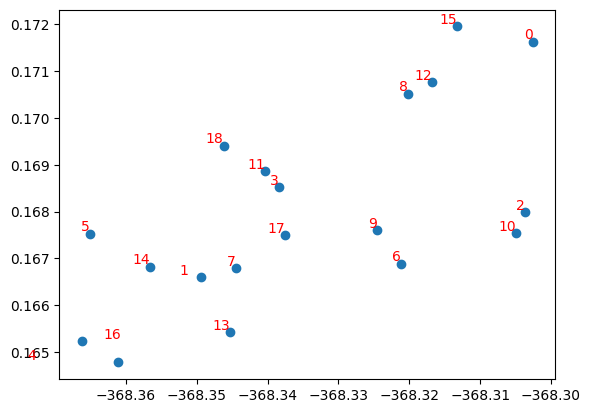

In [14]:
plt.scatter(gt_rewards_v2, preds)
for i, (x, y) in enumerate(zip(gt_rewards, preds)):
    plt.text(x, y, str(i), fontsize=10, ha='right', va='bottom', color='red')

In [124]:
from scipy.stats import spearmanr, pearsonr

spearmanr(gt_rewards, preds)


SignificanceResult(statistic=np.float64(0.7172932330827068), pvalue=np.float64(0.0003711409336667313))

In [125]:
pearsonr(gt_rewards, preds)

PearsonRResult(statistic=np.float64(0.6864949383570004), pvalue=np.float64(0.0008295696820065782))

In [23]:
i = 1
m1 = np.load(DIR / f'cfx/loss_masks_global_{i}.npy')
m2 = np.load(DIR / f'cfx_v2/loss_masks_global_{i}.npy')
m3 = np.load(DIR / f'cfx_v3/loss_masks_global_{i}.npy')

In [21]:
m5 = np.load(DIR / f'cfx_v5/loss_masks_global_{i}.npy')
(m3 == m5).all()


np.False_

In [26]:
# output a grid of m1, m2, m3, m4, m5 similarity matrix
s = ''
for m in [m1, m2, m3, m4, m5]:
    for n in [m1, m2, m3, m4, m5]:
        s += f'{(m == n).mean():.3f} '
    s += '\n'
print(s)

1.000 0.617 0.859 0.616 0.616 
0.617 1.000 0.476 0.997 0.997 
0.859 0.476 1.000 0.475 0.475 
0.616 0.997 0.475 1.000 1.000 
0.616 0.997 0.475 1.000 1.000 



In [24]:
(m2 == m5).mean()

np.float64(0.9973870442708334)

In [ ]:
gt_rewards = []
gt_rewards_v2 = []
gt_rewards_v3 = []
gt_rewards_v4 = []
gt_rewards_v5 = []
preds = []

T = 2_100
BS = 1024
total = (12000 - 2100) * BS

for i in range(20):
    if not (DIR / f'cfx_v4/{i}.npy').exists() or not (DIR / f'cfx_v5/{i}.npy').exists():
        continue
    path = DIR / f'cfx/{i}.npy'
    reward = np.load(path)
    path = DIR / f'cfx_v2/{i}.npy'
    reward_v2 = np.load(path)
    path = DIR / f'cfx_v3/{i}.npy'
    reward_v3 = np.load(path)
    path = DIR / f'cfx_v4/{i}.npy'
    reward_v4 = np.load(path)
    path = DIR / f'cfx_v5/{i}.npy'
    reward_v5 = np.load(path)
    loss_mask = np.load(DIR / f'cfx_v4/loss_masks_global_{i}.npy')
    print(loss_mask.shape)
    preds.append(np.dot(loss_mask[T*BS:], metagrads[T*BS:]).item())
    gt_rewards.append(reward)
    gt_rewards_v2.append(reward_v2)
    gt_rewards_v3.append(reward_v3)
    gt_rewards_v4.append(reward_v4)
    gt_rewards_v5.append(reward_v5)
    #print(preds)
    #print(loss_mask.shape)
    #print(reward)
    print(f'ratio {i}:', (total - loss_mask[2100:].sum()) / total)

(12288000,)
ratio 0: 0.40406841856060605
(12288000,)
ratio 1: 0.0015931778724747475
(12288000,)
ratio 2: 0.001208471433080808
(12288000,)
ratio 3: 0.0011411971275252526
(12288000,)
ratio 4: 0.0009202375315656566
(12288000,)
ratio 5: 0.394070983270202
(12288000,)
ratio 6: 0.0008423098169191919
(12288000,)
ratio 7: 0.0009404592803030303
(12288000,)
ratio 8: 0.0004219933712121212
(12288000,)
ratio 9: 0.0004313644255050505


In [57]:
6139126 // 1024

5995

In [4]:
gt_rewards_v4 = []
gt_rewards_v5 = []
preds = []

T = 2_100
BS = 1024
total = (12000 - 2100) * BS

indices = []
for i in range(40):
    if not (DIR / f'cfx_v5/{i}.npy').exists() or not (DIR / f'cfx_v4/{i}.npy').exists():
        continue
    path = DIR / f'cfx_v5/{i}.npy'
    reward = np.load(path)
    path = DIR / f'cfx_v4/{i}.npy'
    reward_v2 = np.load(path)
    gt_rewards_v5.append(reward)
    gt_rewards_v4.append(reward_v2)

    print(i, reward, reward_v2)

    loss_mask_s = np.load(DIR / f'cfx_v4/loss_masks_global_{i}.npy')
    loss_mask_ns = np.load(DIR / f'cfx_v5/loss_masks_global_{i}.npy')
    #print(loss_mask_s.shape, loss_mask_ns.shape)
    print(i, (loss_mask_s == loss_mask_ns).mean(), loss_mask_s.sum(), loss_mask_ns.sum())
    if (loss_mask_s == loss_mask_ns).mean() < 0.01:
        indices.append(i)
    preds.append(np.dot(loss_mask_s[T*BS:], metagrads[T*BS:]).item())
    #print(preds)
    #print(loss_mask.shape)
    #print(reward)
    print(f'ratio {i}:', (total - loss_mask_s[2100:].sum()) / total)
    print()

0 -368.02524 -368.02393
0 0.6804453125 6041316 9968004
ratio 0: 0.40406841856060605

1 -367.9413 -367.9413
1 1.0 10121449 10121449
ratio 1: 0.0015931778724747475

2 -367.97876 -367.97876
2 1.0 10125349 10125349
ratio 2: 0.001208471433080808

3 -367.95636 -367.95636
3 1.0 10126031 10126031
ratio 3: 0.0011411971275252526

4 -367.93076 -367.93076
4 1.0 10128271 10128271
ratio 4: 0.0009202375315656566

5 -367.9335 -367.95157
5 0.6750697428385417 6142666 10135409
ratio 5: 0.394070983270202

6 -367.96878 -367.9726
6 0.6752733561197917 10129061 6138820
ratio 6: 0.0008423098169191919

7 -367.91568 -367.93414
7 0.6753009440104166 10128066 6138164
ratio 7: 0.0009404592803030303

8 -367.95453 -367.95453
8 1.0 10133322 10133322
ratio 8: 0.0004219933712121212

9 -367.9585 -367.9585
9 1.0 10133227 10133227
ratio 9: 0.0004313644255050505



In [61]:
gt_rewards_s = []
gt_rewards_ns = []
preds = []

T = 2_100
BS = 1024
total = (12000 - 2100) * BS

indices = []
for i in range(40):
    if not (DIR / f'cfx_v4_ns/{i}.npy').exists() or not (DIR / f'cfx_v4/{i}.npy').exists():
        continue
    path = DIR / f'cfx_v4_ns/{i}.npy'
    reward = np.load(path)
    gt_rewards_s.append(reward)
    path = DIR / f'cfx_v4/{i}.npy'
    reward_v2 = np.load(path)
    gt_rewards_ns.append(reward_v2)

    loss_mask_s = np.load(DIR / f'cfx_v4/loss_masks_global_{i}.npy')
    loss_mask_ns = np.load(DIR / f'cfx_v4_ns/loss_masks_global_{i}.npy')
    #print(loss_mask_s.shape, loss_mask_ns.shape)
    print(i, (loss_mask_s == loss_mask_ns).mean(), loss_mask_s.sum(), loss_mask_ns.sum())
    if (loss_mask_s == loss_mask_ns).mean() < 0.01:
        indices.append(i)
    preds.append(np.dot(loss_mask_s[T*BS:], metagrads[T*BS:]).item())
    #print(preds)
    #print(loss_mask.shape)
    #print(reward)
    print(f'ratio {i}:', (total - loss_mask_s[2100:].sum()) / total)

0 0.6804453125 6041316 9968004
ratio 0: 0.40406841856060605
2 1.0 10125349 10125349
ratio 2: 0.001208471433080808
5 0.6750697428385417 6142666 10135409
ratio 5: 0.394070983270202
6 1.0 10129061 10129061
ratio 6: 0.0008423098169191919
7 1.0 10128066 10128066
ratio 7: 0.0009404592803030303
8 1.0 10133322 10133322
ratio 8: 0.0004219933712121212
10 1.0 10121621 10121621
ratio 10: 0.001576211332070707
13 1.0 10131629 10131629
ratio 13: 0.000588995422979798
14 1.0 10132893 10132893
ratio 14: 0.00046431107954545455
15 0.6752621256510417 6139126 10129505
ratio 15: 0.3944201783459596
16 1.0 10133818 10133818
ratio 16: 0.00037306660353535355
17 0.67519287109375 6140347 10131577
ratio 17: 0.39429973563762627
18 1.0 10133708 10133708
ratio 18: 0.00038391729797979796
20 1.0 10103651 10103651
ratio 20: 0.0033488202335858587
21 1.0 10135895 10135895
ratio 21: 0.0001681857638888889
22 1.0 10133203 10133203
ratio 22: 0.0004337318497474747
23 1.0 10133242 10133242
ratio 23: 0.00042988478535353536
24 0.6

In [52]:
import scipy.stats
scipy.stats.spearmanr(gt_rewards_s, gt_rewards_ns)

SignificanceResult(statistic=np.float64(0.405911330049261), pvalue=np.float64(0.028904654212987466))

In [55]:
indices

[]

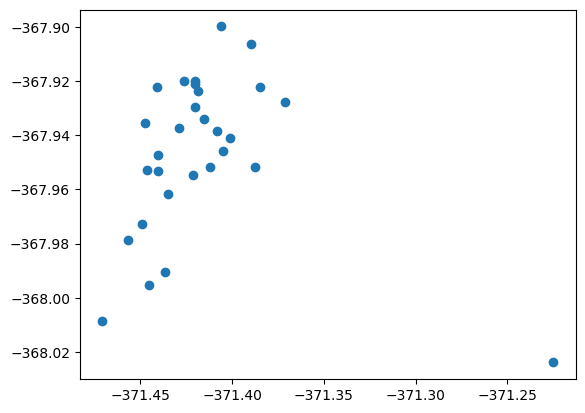

In [62]:
plt.scatter(np.array(gt_rewards_s), np.array(gt_rewards_ns))

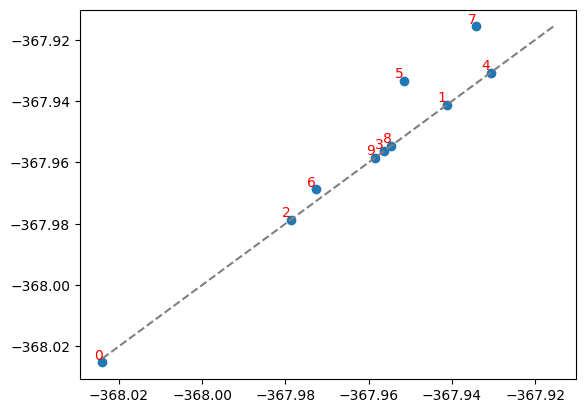

In [7]:
plt.scatter(gt_rewards_v4, gt_rewards_v5)

m, M = min(gt_rewards_v4), max(gt_rewards_v5)
plt.plot([m,M], [m,M], linestyle='--', color='grey')

for i, (x, y) in enumerate(zip(gt_rewards_v4, gt_rewards_v5)):
    plt.text(x, y, str(i), fontsize=10, ha='right', va='bottom', color='red')

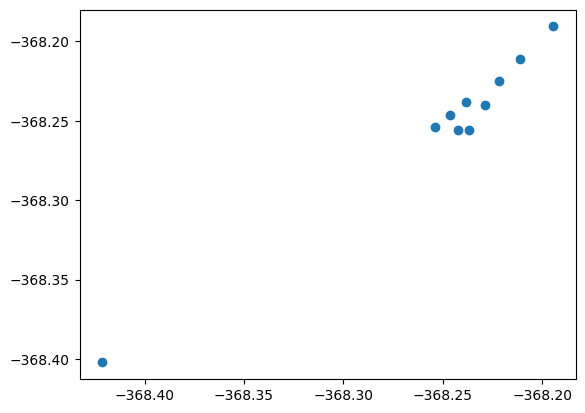

In [ ]:
plt.scatter(gt_rewards_v2, gt_rewards_v3)
for i, (x, y) in enumerate(zip(gt_rewards, gt_rewards_v2)):
    plt.text(x, y, str(i), fontsize=10, ha='right', va='bottom', color='red')

In [79]:
i = 5
loss_mask = np.load(DIR / f'cfx/loss_masks_global_{i}.npy')

total = (12000 - 2100) * BS
(total - loss_mask[2100:].sum()) / total

np.float64(0.4445624210858586)

In [78]:
for i in range(2100, 12000, 50):
    print(i, loss_mask[i * BS:(i+50) * BS].mean())

2100 0.99890625
2150 0.99912109375
2200 0.99923828125
2250 0.9990234375
2300 0.999140625
2350 0.99888671875
2400 0.99908203125
2450 0.99919921875
2500 0.99923828125
2550 0.99896484375
2600 0.99923828125
2650 0.99904296875
2700 0.99916015625
2750 0.99919921875
2800 0.99908203125
2850 0.99916015625
2900 0.99904296875
2950 0.9990234375
3000 0.99912109375
3050 0.999375
3100 0.99892578125
3150 0.99904296875
3200 0.9988671875
3250 0.99919921875
3300 0.9991796875
3350 0.9989453125
3400 0.9992578125
3450 0.99892578125
3500 0.9988671875
3550 0.99890625
3600 0.9989453125
3650 0.9991796875
3700 0.9988671875
3750 0.99896484375
3800 0.998984375
3850 0.998984375
3900 0.9991015625
3950 0.9992578125
4000 0.99912109375
4050 0.99912109375
4100 0.99916015625
4150 0.99892578125
4200 0.99892578125
4250 0.99908203125
4300 0.99923828125
4350 0.998828125
4400 0.9990234375
4450 0.99912109375
4500 0.99921875
4550 0.99900390625
4600 0.99873046875
4650 0.99904296875
4700 0.99896484375
4750 0.99896484375
4800 0.99

In [98]:
for i in range(20):
    loss_mask = np.load(DIR / f'cfx_v2/loss_masks_global_{i}.npy')
    batch_avg = []
    for j in range(2100, 12000, 50):
        batch_avg.append(loss_mask[j * BS:(j+50) * BS].mean())
    batch_avg = np.array(batch_avg)
    print(i, np.where(batch_avg != 0)[0][0])

0 0
1 0
2 0
3 0
4 0
5 0
6 172
7 0
8 0
9 18
10 0
11 0
12 0
13 0
14 34
15 0
16 0
17 186
18 0
19 0


In [ ]:
np.where(loss_mask != 0)[0] / 1024   # started finetuning from iter 2100

array([ 2100.        ,  2100.00097656,  2100.00195312, ...,
       11999.99707031, 11999.99804688, 11999.99902344], shape=(10133529,))

In [32]:
preds[0]

0.1783645896475376

In [33]:
preds[16]

0.1777739349390674

In [34]:
preds[19]

0.17761674631880336

In [44]:
for i in range(20):
    print(i, preds[i])

0 0.010472665545858462
1 0.010929987942620567
2 0.010946148009715273
3 0.010823110995862972
4 0.010815462422224309
5 0.01089553077856964
6 0.011010907448889995
7 0.010834862848084992
8 0.010874059271948067
9 0.010863849873444131
10 7.60860073643066e-05
11 0.011230986871371584
12 0.010902285130397704
13 0.01109078532911223
14 0.010773821460482447
15 0.011026515270164072
16 0.010965268697253894
17 0.010878734751828656
18 0.010865346661929731
19 0.010871389923091446


In [ ]:
ratio 0: 0.016758601641414142
ratio 4: 0.0009314827967171717
ratio 6: 0.0008281052714646464
ratio 8: 0.00043156171085858587
ratio 9: 0.0004276160037878788
ratio 14: 0.0004661852904040404
ratio 16: 0.00037553267045454543
ratio 17: 0.0005937302714646464
ratio 18: 0.0003715869633838384
ratio 19: 0.0004015743371212121

[0, 4, 6, 8, 9, 14, 16, 17, 18, 19]

In [137]:
gt_rewards = np.array(gt_rewards)
gt_rewards_v2 = np.array(gt_rewards_v2)
preds = np.array(preds)
indices = [0, 1, 2, 3, 4, 5, 7, 8, 10, 11, 12, 13, 15, 16, 18, 19]

(array([1., 0., 0., 0., 0., 0., 1., 4., 7., 7.]),
 array([-368.42126465, -368.39859009, -368.37588501, -368.35321045,
        -368.33050537, -368.30783081, -368.28515625, -368.26245117,
        -368.23977661, -368.21707153, -368.19439697]),
 <BarContainer object of 10 artists>)

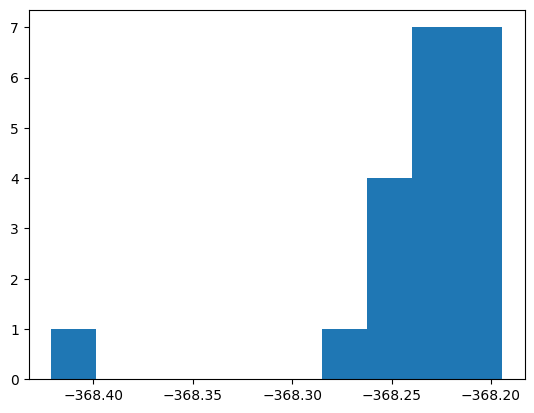

In [104]:
plt.hist(gt_rewards)

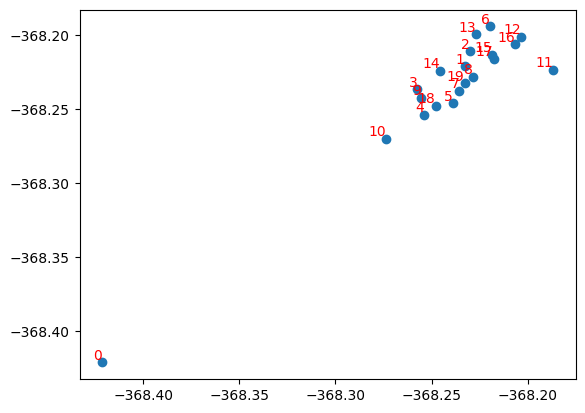

In [116]:
plt.scatter(gt_rewards, gt_rewards_v2)
for i, (x, y) in enumerate(zip(gt_rewards, gt_rewards_v2)):
    plt.text(x, y, str(i), fontsize=10, ha='right', va='bottom', color='red')

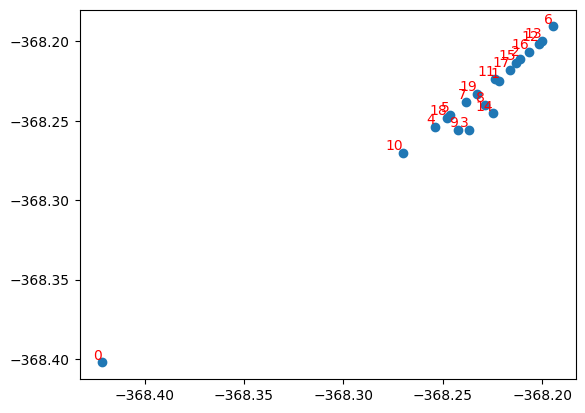

In [119]:
plt.scatter(gt_rewards_v2, gt_rewards_v3)
for i, (x, y) in enumerate(zip(gt_rewards_v2, gt_rewards_v3)):
    plt.text(x, y, str(i), fontsize=10, ha='right', va='bottom', color='red')

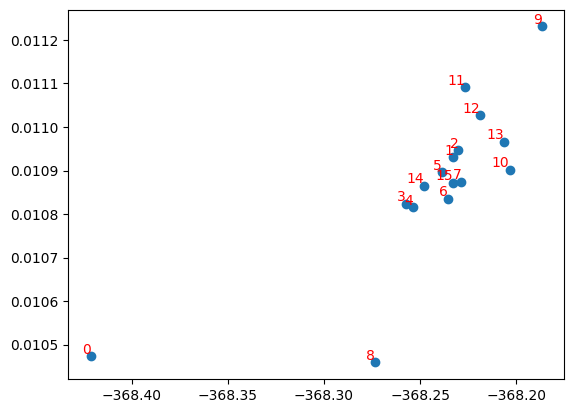

In [139]:
plt.scatter(gt_rewards[indices], preds[indices])
for i, (x, y) in enumerate(zip(gt_rewards[indices], preds[indices])):
    plt.text(x, y, str(i), fontsize=10, ha='right', va='bottom', color='red')

In [41]:
import numpy as np
import glob
from pathlib import Path

def parse_dir(DIR, step):
    files = sorted(glob.glob(str(DIR / f"step-0{step}.tokens.npy.r*")))

    # Load the first file to infer shape
    sample = np.load(files[0], mmap_mode="r")
    batch_shape = sample.shape
    print("Single shard shape:", batch_shape)

    # Initialize final reconstructed batch
    full = np.zeros(batch_shape, dtype=sample.dtype)

    for f in files:
        arr = np.load(f)
        # Identify which rows are nonzero (assuming entire row must be nonzero to count)
        nonzero_rows = np.any(arr != 0, axis=1)
        count = nonzero_rows.sum()
        print(f"{f}: {count} nonzero rows")
        # Overwrite those rows
        full[nonzero_rows] = arr[nonzero_rows]

    # Verify reconstruction
    print("Final nonzero rows:", np.any(full != 0, axis=1).sum())
    print("Sample values:\n", full[:10])
    return full

In [33]:
DIR = Path("/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4")
v4_tokens = parse_dir(DIR)


Single shard shape: (1024, 128)
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4/step-011084.tokens.npy.r0: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4/step-011084.tokens.npy.r1: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4/step-011084.tokens.npy.r2: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4/step-011084.tokens.npy.r3: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4/step-011084.tokens.npy.r4: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4/step-011084.tokens.npy.r5: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4/step-011084.tokens.npy.r6: 128 nonzero 

In [34]:
DIR = Path("/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v5")
v5_tokens = parse_dir(DIR)

Single shard shape: (1024, 128)
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v5/step-011084.tokens.npy.r0: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v5/step-011084.tokens.npy.r1: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v5/step-011084.tokens.npy.r2: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v5/step-011084.tokens.npy.r3: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v5/step-011084.tokens.npy.r4: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v5/step-011084.tokens.npy.r5: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v5/step-011084.tokens.npy.r6: 128 nonzero 

In [35]:
np.where(v4_tokens != v5_tokens)

(array([], dtype=int64), array([], dtype=int64))

In [42]:
DIR = Path("/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11122/v4")
v4_tokens = parse_dir(DIR, 11122)
DIR = Path("/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11122/v5")
v5_tokens = parse_dir(DIR, 11122)

Single shard shape: (1024, 128)
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11122/v4/step-011122.tokens.npy.r0: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11122/v4/step-011122.tokens.npy.r1: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11122/v4/step-011122.tokens.npy.r2: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11122/v4/step-011122.tokens.npy.r3: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11122/v4/step-011122.tokens.npy.r4: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11122/v4/step-011122.tokens.npy.r5: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11122/v4/step-011122.tokens.npy.r6: 128 nonzero 

In [45]:
(v4_tokens == v5_tokens).all()

np.True_

In [44]:
(v4_tokens != v5_tokens).any()

np.False_

In [ ]:
tokens[]

array([[ 2832,    11,   290, ...,  5242,   286,   812],
       [   83, 12195,   325, ...,  1438,    30,   198],
       [ 8142,  3259,   447, ...,   428,  3842,   262],
       ...,
       [  257,  3218,   636, ..., 22014,   286,  4202],
       [   13,  4132,    81, ...,    13,   300,   590],
       [  247,    82,  2694, ...,  8354,    13, 19672]],
      shape=(8192, 128), dtype=int32)

In [24]:
np.where(tokens[:1024].sum(1) != 0)

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31, 128, 129, 130, 131, 132, 133, 134,
        135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147,
        148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 512,
        513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525,
        526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538,
        539, 540, 541, 542, 543, 640, 641, 642, 643, 644, 645, 646, 647,
        648, 649, 650, 651, 652, 653, 654, 655, 656, 657, 658, 659, 660,
        661, 662, 663, 664, 665, 666, 667, 668, 669, 670, 671]),)

In [25]:
np.where(tokens[1024:2048].sum(1) != 0)

(array([256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268,
        269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281,
        282, 283, 284, 285, 286, 287, 384, 385, 386, 387, 388, 389, 390,
        391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403,
        404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 768,
        769, 770, 771, 772, 773, 774, 775, 776, 777, 778, 779, 780, 781,
        782, 783, 784, 785, 786, 787, 788, 789, 790, 791, 792, 793, 794,
        795, 796, 797, 798, 799, 896, 897, 898, 899, 900, 901, 902, 903,
        904, 905, 906, 907, 908, 909, 910, 911, 912, 913, 914, 915, 916,
        917, 918, 919, 920, 921, 922, 923, 924, 925, 926, 927]),)

In [29]:
import numpy as np
import glob
from pathlib import Path

DIR = Path("/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4")
files = sorted(glob.glob(str(DIR / "step-011084.tokens.npy.r*")))

sample = np.load(files[0], mmap_mode="r")
n_rows = sample.shape[0]
coverage = np.zeros(n_rows, dtype=bool)

for f in files:
    arr = np.load(f)
    nonzero_rows = np.any(arr != 0, axis=1)
    overlap = coverage & nonzero_rows
    if overlap.any():
        print(f"⚠️ Overlap detected in {f} at rows:", np.where(overlap)[0])
    coverage |= nonzero_rows
    print(f"{f}: {nonzero_rows.sum()} nonzero rows")

missing_rows = np.where(~coverage)[0]
if len(missing_rows) > 0:
    print(f"⚠️ {len(missing_rows)} rows were never written:", missing_rows)
else:
    print("✅ All rows are covered by at least one shard (no missing).")


/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4/step-011084.tokens.npy.r0: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4/step-011084.tokens.npy.r1: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4/step-011084.tokens.npy.r2: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4/step-011084.tokens.npy.r3: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4/step-011084.tokens.npy.r4: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4/step-011084.tokens.npy.r5: 128 nonzero rows
/juice5b/scr5b/sampark/marin/results/gpt2-train-fineweb-two-phases-v1-full/debug/step-11084/v4/step-011084.tokens.npy.r6: 128 nonzero rows
/juice5b/scr5b/sampark/mari

In [27]:
sum(tokens[1024*2:1024*3].sum(1) != 0)


np.int64(128)

In [21]:
tokens[1024:2048].sum()

np.int64(81134668)

In [16]:
tokens[:,0] != 0

array([ True,  True,  True, ...,  True,  True,  True], shape=(8192,))